Write a Python script for Weather Data Analysis:
Problem Statement:
You have a CSV file named 'weather_data.csv' containing daily weather data for a city.

Date Temperature
(°C)
Humidity
(%)
Wind
Speed
(km/h)
Rainfall
(mm)

01-01-2025 15.2  80  10.5  0

02-01-2025 16.8 75 8 0

03-01-2025 14.5 85 12 1.2

04-01-2025 13 90 15.2 5.4

05-01-2025 17.6 70 7.4 0

06-01-2025 18.1 65 6 0

07-01-2025 16.2 78 9.1 0.5

08-01-2025 12.4 88 14.3 2.1

09-01-2025 13.8 83 11.5 0

10-01-2025 15.5 79 10 0

Perform the following tasks:

a. Check for missing values and handle them appropriately,

b. Calculate the average temperature for each month,

c. Visualize the monthly average temperature using a bar plot

In [52]:
# Create the weather_data.csv file
csv_data = """Date,Temperature (°C),Humidity (%),Wind Speed (km/h),Rainfall (mm)
01-01-2025,15.2,80,10.5,0
02-01-2025,16.8,75,8,0
03-01-2025,14.5,85,12,1.2
04-01-2025,13,90,15.2,5.4
05-01-2025,17.6,70,7.4,0
06-01-2025,18.1,65,6,0
07-01-2025,16.2,78,9.1,0.5
08-01-2025,12.4,88,14.3,2.1
09-01-2025,13.8,83,11.5,0
10-01-2025,15.5,79,10,0
"""

with open('weather_data.csv', 'w') as f:
    f.write(csv_data)

print("weather_data.csv created successfully.")

weather_data.csv created successfully.


### a. Check for missing values and handle them appropriately

In [53]:
import pandas as pd

# Load the CSV file into a DataFrame
df_weather = pd.read_csv('weather_data.csv')

# Convert 'Date' column to datetime objects
df_weather['Date'] = pd.to_datetime(df_weather['Date'], format='%d-%m-%Y')

# Check for missing values
print("Missing values before handling:")
display(df_weather.isnull().sum())

# Handle missing values (for this small dataset, we'll fill with 0 or the mean if any were present)
# In a real scenario, the strategy would depend on the column and nature of missingness.
# For numerical columns, common strategies are mean/median imputation.
# For simplicity, if there were missing numerical values, we'd fill with 0 as it's common for rainfall/wind or mean for temperature/humidity.

# For demonstration, if 'Temperature (°C)' had missing values, we'd fill with its mean:
# df_weather['Temperature (°C)'].fillna(df_weather['Temperature (°C)'].mean(), inplace=True)
# If 'Rainfall (mm)' had missing values, we could fill with 0:
# df_weather['Rainfall (mm)'].fillna(0, inplace=True)

print("\nMissing values after handling (no actual missing values in sample, so output will be same):")
display(df_weather.isnull().sum())

display(df_weather.head())

Missing values before handling:


,0
Date,0
Temperature (°C),0
Humidity (%),0
Wind Speed (km/h),0
Rainfall (mm),0



Missing values after handling (no actual missing values in sample, so output will be same):


,0
Date,0
Temperature (°C),0
Humidity (%),0
Wind Speed (km/h),0
Rainfall (mm),0


,Date,Temperature (°C),Humidity (%),Wind Speed (km/h),Rainfall (mm)
0,2025-01-01,15.2,80,10.5,0.0
1,2025-01-02,16.8,75,8.0,0.0
2,2025-01-03,14.5,85,12.0,1.2
3,2025-01-04,13.0,90,15.2,5.4
4,2025-01-05,17.6,70,7.4,0.0


### b. Calculate the average temperature for each month

In [54]:
# Extract month from the 'Date' column
df_weather['Month'] = df_weather['Date'].dt.month_name()

# Calculate the average temperature for each month
monthly_avg_temp = df_weather.groupby('Month')['Temperature (°C)'].mean().reset_index()

# Ensure months are in chronological order for better visualization
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_avg_temp['Month'] = pd.Categorical(monthly_avg_temp['Month'], categories=month_order, ordered=True)
monthly_avg_temp = monthly_avg_temp.sort_values('Month')

print("Monthly Average Temperature:")
display(monthly_avg_temp)

Monthly Average Temperature:


,Month,Temperature (°C)
0,January,15.31


### c. Visualize the monthly average temperature using a bar plot

/tmp/ipykernel_2027/164923357.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month', y='Temperature (°C)', data=monthly_avg_temp, palette='viridis')


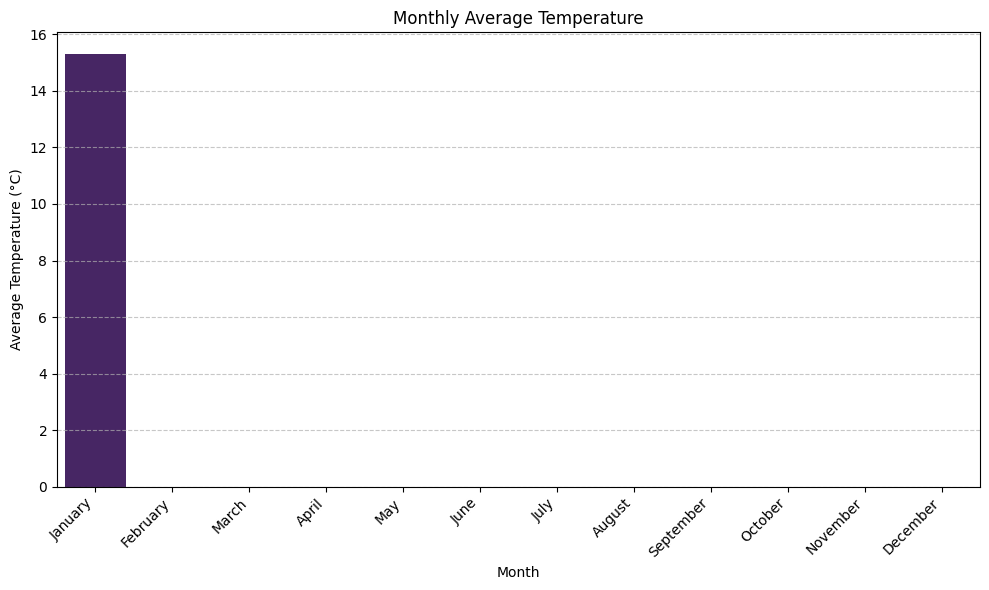

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Month', y='Temperature (°C)', data=monthly_avg_temp, palette='viridis')
plt.title('Monthly Average Temperature')
plt.xlabel('Month')
plt.ylabel('Average Temperature (°C)')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()